# AGUVIS inference playground

Use this notebook to load an AGUVIS checkpoint and run a few inference cases against a test image.

Suggested setup:

```bash
conda env create -f environment.yml
conda activate aguvis-inference
python -m ipykernel install --user --name aguvis-inference --display-name "Python (aguvis-inference)"
jupyter lab
```

Notes:
- Set `MODEL_PATH` to a local checkpoint directory or a Hugging Face model id.
- CUDA is strongly recommended. The notebook falls back to eager attention if `flash-attn` is not installed.
- The notebook imports the repo directly from `src/`, so it does not need `pip install -e .`.


In [1]:
from pathlib import Path
import os
import sys

repo_root = Path.cwd()
if not (repo_root / "src" / "aguvis").exists():
    repo_root = Path("/home/tuq24452/code/GUIAgent/aguvis")

os.chdir(repo_root)
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

print(f"repo_root={repo_root}")


repo_root=/home/tuq24452/code/GUIAgent/aguvis


In [2]:
import importlib.util

import torch

MODEL_PATH = "xlangai/Aguvis-7B-720P"
IMAGE_PATH = repo_root / "src/aguvis/serve/examples/AndroidControl.png"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ATTN_IMPLEMENTATION = (
    "flash_attention_2"
    if DEVICE == "cuda" and importlib.util.find_spec("flash_attn") is not None
    else "eager"
)
TORCH_DTYPE = torch.bfloat16 if DEVICE == "cuda" else None
TEMPERATURE = 0.0
MAX_NEW_TOKENS = 512

DEFAULT_INSTRUCTION = "In the BBC News app, turn on the news alert notification for the BBC News app."

print(
    {
        "model_path": MODEL_PATH,
        "image_path": str(IMAGE_PATH),
        "device": DEVICE,
        "cuda_device_count": torch.cuda.device_count(),
        "attn_implementation": ATTN_IMPLEMENTATION,
    }
)

if DEVICE != "cuda":
    print("Warning: CUDA is not visible to this kernel. Qwen2-VL inference will be very slow or may fail.")


{'model_path': 'xlangai/Aguvis-7B-720P', 'image_path': '/home/tuq24452/code/GUIAgent/aguvis/src/aguvis/serve/examples/AndroidControl.png', 'device': 'cuda', 'cuda_device_count': 4, 'attn_implementation': 'eager'}


In [3]:
from IPython.display import Markdown, display

from aguvis.serve.cli import generate_response, load_image, load_pretrained_model


def load_aguvis_model(model_path: str, device: str = DEVICE):
    model, processor, tokenizer = load_pretrained_model(
        model_path,
        attn_implementation=ATTN_IMPLEMENTATION,
        torch_dtype=TORCH_DTYPE,
    )
    model.to(device)
    model.tie_weights()
    return model, processor, tokenizer


def pretty_print_response(title: str, response: str):
    display(Markdown(f"### {title}"))
    print(response)


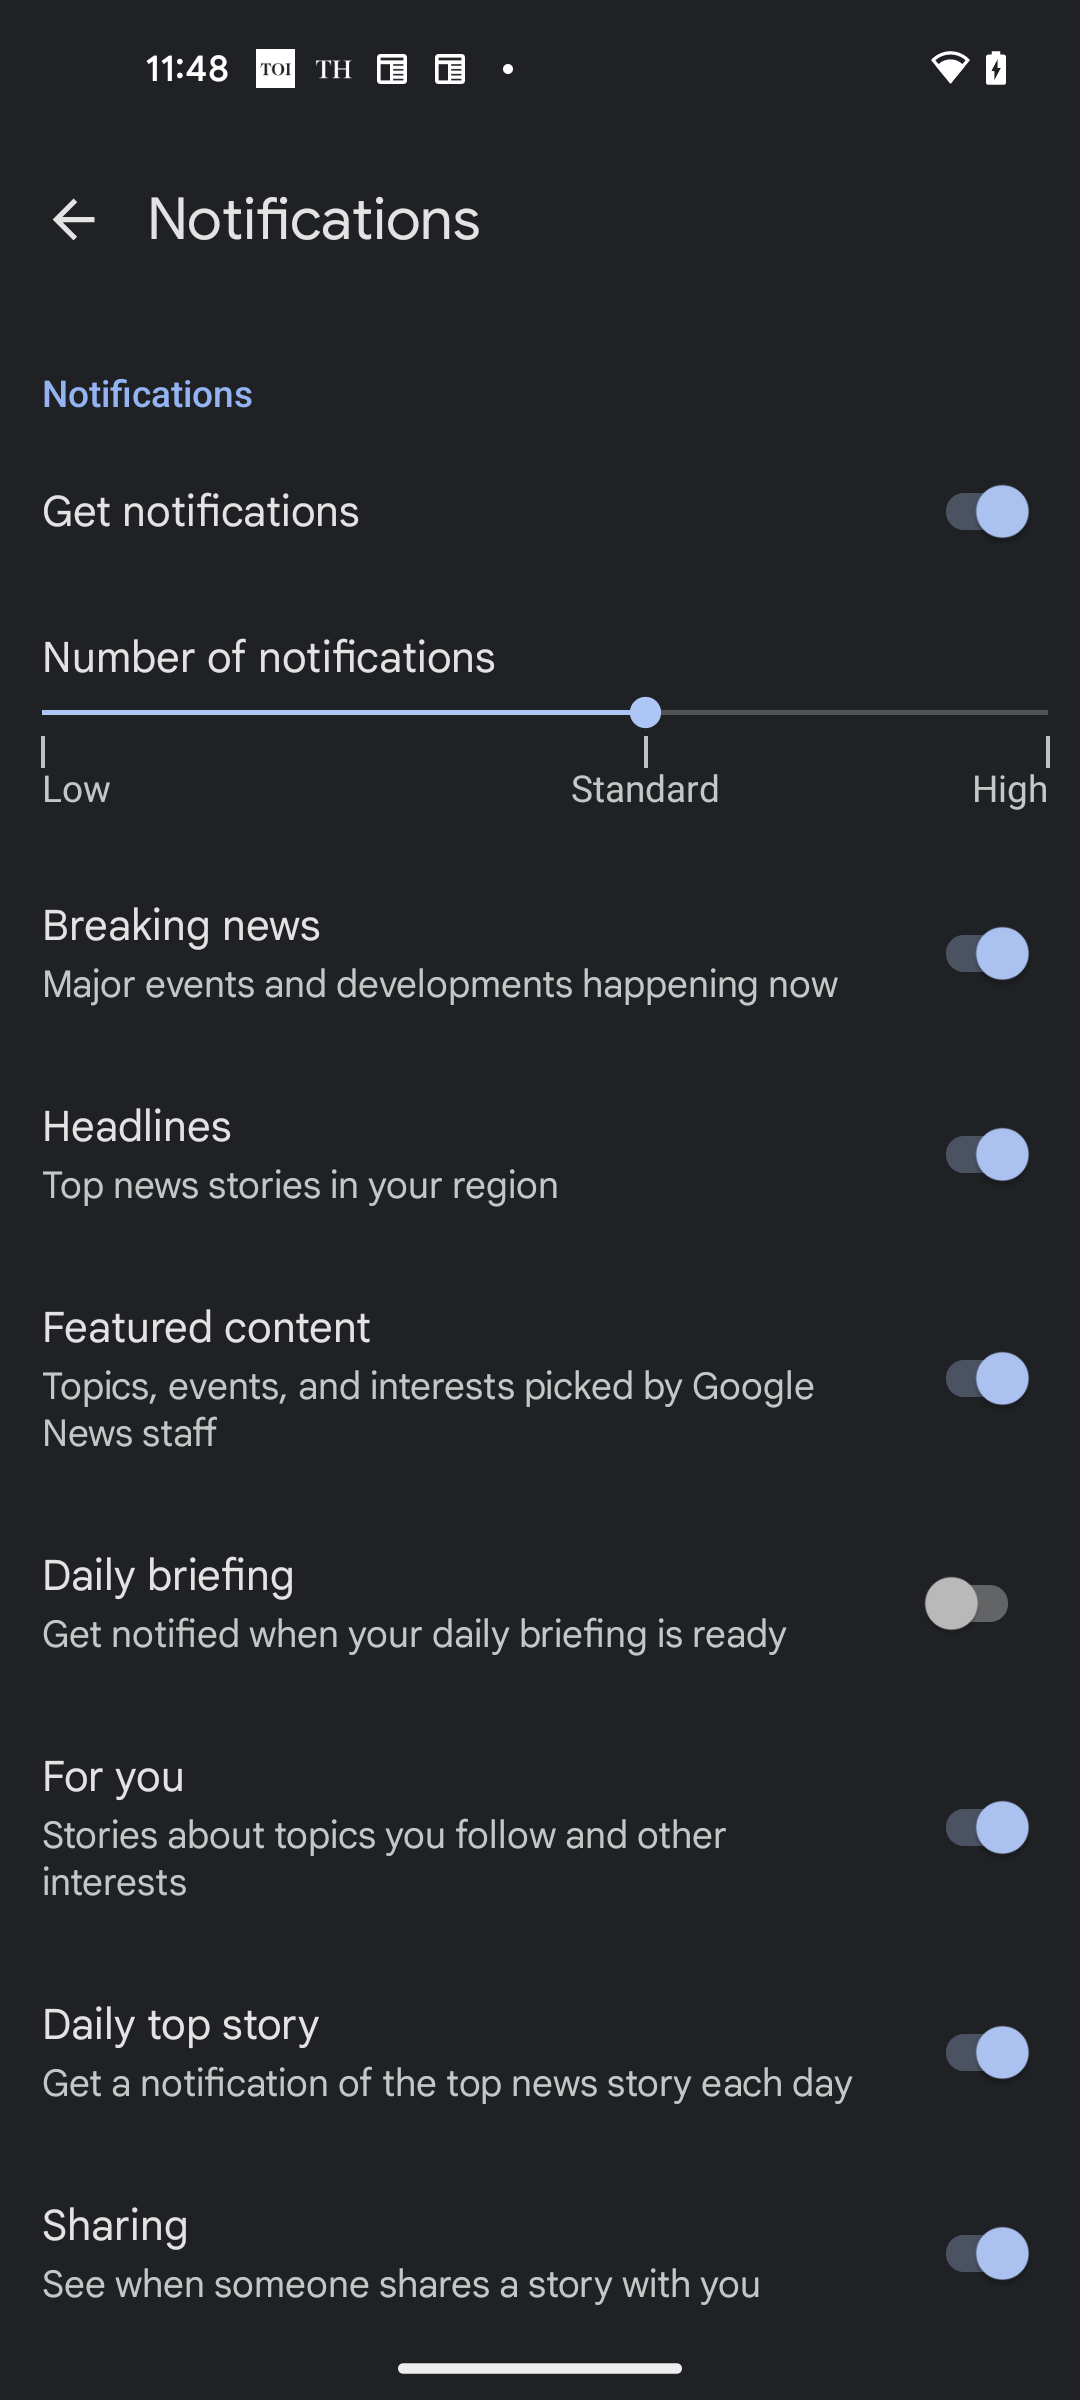

/home/tuq24452/anaconda3/envs/aguvis-inference/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46
Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00,  4.21it/s]


Model loaded.


In [4]:
image = load_image(str(IMAGE_PATH))
display(image)

model, processor, tokenizer = load_aguvis_model(MODEL_PATH)
print("Model loaded.")


In [7]:
DEFAULT_INSTRUCTION

'In the BBC News app, turn on the news alert notification for the BBC News app.'

In [ ]:
EXAMPLES = [
    {
        "title": "Example 1: default self-plan",
        "instruction": DEFAULT_INSTRUCTION,
        "mode": "self-plan",
        "previous_actions": None,
        "low_level_instruction": None,
    },
    {
        "title": "Example 2: self-plan with history",
        "instruction": "In the BBC News app, enable breaking news notifications.",
        "mode": "self-plan",
        "previous_actions": [
            "Step 1: Open the BBC News app.",
            "Step 2: Navigate to the settings page.",
        ],
        "low_level_instruc;tion": None,
    },
    {
        "title": "Example 3: force-plan",
        "instruction": "Open settings and look for notification options.",
        "mode": "force-plan",
        "previous_actions": None,
        "low_level_instruction": None,
    },
    {
        "title": "Example 4: grounding mode",
        "instruction": "Tap the Notifications option.",
        "mode": "grounding",
        "previous_actions": None,
        "low_level_instruction": "Tap the Notifications option",
    },
]


def run_example(example: dict, temperature: float = TEMPERATURE, max_new_tokens: int = MAX_NEW_TOKENS):
    response = generate_response(
        model=model,
        processor=processor,
        tokenizer=tokenizer,
        image=image,
        instruction=example["instruction"],
        previous_actions=example.get("previous_actions"),
        low_level_instruction=example.get("low_level_instruction"),
        mode=example.get("mode", "self-plan"),
        temperature=temperature,
        max_new_tokens=max_new_tokens,
    )
    print('###'*5)
    print('## Title:', example["title"])
    print('## Instruction:', example["instruction"])
    print('## Previous Actions:', example.get("previous_actions"))
    print('## Response: ', response)
    return response


In [19]:
results = []
for example in EXAMPLES:
    results.append(run_example(example))


/home/tuq24452/anaconda3/envs/aguvis-inference/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:151658 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151658 for open-end generation.


###############
## Title: Example 1: default self-plan
## Instruction: In the BBC News app, turn on the news alert notification for the BBC News app.
## Previous Actions: None
## Response:  all
Action: Open the BBC News app

assistantos
mobile.open_app(app_name='BBC News')


Setting `pad_token_id` to `eos_token_id`:151658 for open-end generation.


###############
## Title: Example 2: self-plan with history
## Instruction: In the BBC News app, enable breaking news notifications.
## Previous Actions: ['Step 1: Open the BBC News app.', 'Step 2: Navigate to the settings page.']
## Response:  all
Action: Toggle on the breaking news notifications.

assistantos
pyautogui.click(x=0.90463, y=0.3971)


Setting `pad_token_id` to `eos_token_id`:151658 for open-end generation.


###############
## Title: Example 3: force-plan
## Instruction: Open settings and look for notification options.
## Previous Actions: None
## Response:  The goal is to open settings and look for notification options. The current screen is already displaying the notification settings, indicating that the task is complete.
Action: The task is complete, so I will terminate the process successfully.

assistantos
mobile.terminate(status='success')
###############
## Title: Example 4: grounding mode
## Instruction: Tap the Notifications option.
## Previous Actions: None
## Response:  assistantos
pyautogui.click(x=0.5, y=0.167)


In [ ]:
# Free-form playground cell.
custom_response = generate_response(
    model=model,
    processor=processor,
    tokenizer=tokenizer,
    image=image,
    instruction="Replace this instruction with your own task.",
    previous_actions=None,
    low_level_instruction=None,
    mode="self-plan",
    temperature=TEMPERATURE,
    max_new_tokens=MAX_NEW_TOKENS,
)
print(custom_response)
